# Linear Regression from First Principles using Scikit-Learn

In this notebook, we will learn:
1. Load a dataset
2. Understand features and target
3. Split the data
4. Train a Linear Regression model
5. Make predictions
6. Evaluate the model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Why are we importing these libraries?

- NumPy → Numerical calculations
- Pandas → DataFrames
- Matplotlib → Visualization
- fetch_california_housing → Dataset
- train_test_split → Split data into training and testing
- LinearRegression → ML model
- Metrics → Evaluate the model

In [3]:
housing = fetch_california_housing(as_frame=True)

housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Every machine learning problem starts with data.

This dataset contains:

Features (Inputs)
↓

House information

Target (Output)
↓

House price

In [4]:
housing.frame.shape

(20640, 9)

In [5]:
housing.frame.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:
housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
housing.frame.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Separate Features and Target

In [8]:
X = housing.data
y = housing.target

In [9]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

X contains the inputs.

Examples:

- Median Income
- House Age
- Average Rooms

y contains the output.

House Price

The model learns

X → y

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

We don't test a student using the same questions we taught them.

Training Data

↓

Learning

Testing Data

↓

Evaluation

This tells us whether the model learned or memorized.

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [13]:
model = LinearRegression()

This creates an empty Linear Regression model.

At this point,

it knows nothing.

θ₀

θ₁

have not been learned yet.

In [14]:
model.fit(X_train, y_train)

LinearRegression()

fit()

↓

Makes Predictions

↓

Calculates Error

↓

Calculates Cost

↓

Uses Gradient Descent (conceptually)

↓

Learns θ values

In [15]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -37.023277706064235
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


In [16]:
y_pred = model.predict(X_test)

## Understanding the Learned Parameters

**Intercept (θ₀)**: The baseline prediction when all features are zero

**Coefficients (θ₁, θ₂, ...)**: 
- How much each feature affects the house price
- Larger coefficient = stronger impact on price
- Positive coefficient = feature increases price
- Negative coefficient = feature decreases price

In [17]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


## Evaluating the Model with Different Metrics

**MAE (Mean Absolute Error)**: Average prediction error in dollars
- Easy to interpret (same units as target)
- Less sensitive to outliers

**MSE (Mean Squared Error)**: Average squared error
- Penalizes large errors more heavily
- Harder to interpret (squared units)

**RMSE (Root Mean Squared Error)**: Square root of MSE
- Back to original units
- Good balance between MAE and MSE

**R² Score**: How well the model explains the variance (0 to 1)
- 1.0 = perfect fit
- 0.5 = explains 50% of variance
- 0.0 = no better than predicting the mean

In [18]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)

0.5332001304956555


In [19]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

0.5558915986952443


In [20]:
rmse = np.sqrt(mse)
print(rmse)

0.7455813830127763


In [21]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.5757877060324508


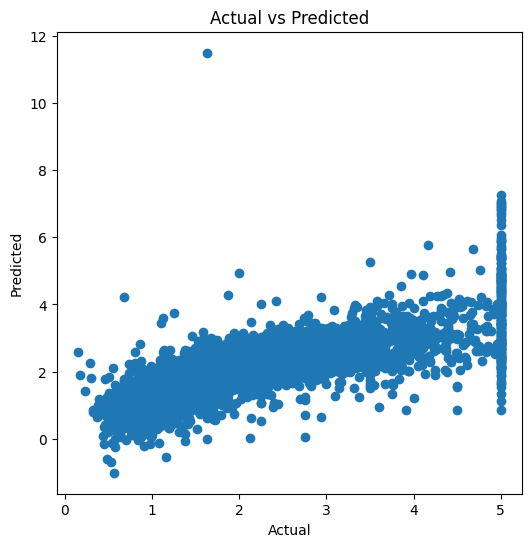

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

## Key Takeaways

✓ **Loaded real-world data** - California Housing Dataset

✓ **Split data** - 80% training, 20% testing

✓ **Trained a model** - Found optimal θ values

✓ **Made predictions** - model.predict() on new data

✓ **Evaluated performance** - Used 4 different metrics

✓ **Visualized results** - Actual vs Predicted scatter plot

## What Makes Linear Regression Powerful?

- **Interpretable**: Can explain which features matter most
- **Fast**: Trains quickly even on large datasets
- **Foundation**: Basis for more advanced algorithms

## Limitations to Remember

- Assumes linear relationship between features and target
- Sensitive to outliers
- May underfit on complex, non-linear patterns

## Next Steps

→ **Multiple Linear Regression**: More features, better predictions

→ **Polynomial Regression**: Capture non-linear patterns

→ **Ridge & Lasso**: Prevent overfitting

## Interpreting the Scatter Plot

**Points on the diagonal line** = Good predictions (actual ≈ predicted)

**Points far from the diagonal** = Poor predictions (large errors)

**Ideal pattern**: All points clustered tightly along the diagonal line

**Common issues**:
- Points above the line = Model underpredicts price
- Points below the line = Model overpredicts price
- Spread pattern = Model struggles with certain price ranges